<a href="https://colab.research.google.com/github/opeoluwa22/Lifestyle-Based-Cervical-Cancer-Risk-Prediction-/blob/main/CERVICAL_CANCER_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lifestyle-Based Cervical Cancer Risk Prediction and Population Burden Analysis in West Africa**



## **1. Cervical Cancer Risk Prediction**
The aim of this project is to develop and evaluate machine learning models for cervical cancer risk prediction using individual-level data. The study uses demographic, behavioural, and medical features to identify patterns associated with biopsy-confirmed outcomes.

Multiple models are compared, and pre-processing techniques such as handling missing values, feature scaling, and class balancing are applied. Performance is evaluated using metrics including accuracy, precision, recall, and F1-score, with emphasis on detecting positive cases.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, accuracy_score

## **PRE-PROCESSING**

In [ ]:
# Load the dataset from the specified CSV file
df = 'https://raw.githubusercontent.com/opeoluwa22/Lifestyle-Based-Cervical-Cancer-Risk-Prediction-/refs/heads/main/data/risk_factors_cervical_cancer.csv'
data = pd.read_csv(df)

# Convert all columns to numeric types, coercing errors to NaN
data = data.apply(pd.to_numeric, errors='coerce')



In [ ]:
# Display columns with missing values and their percentages
missing_values = data.isnull().sum()
missing_percentage = (missing_values / len(data)) * 100
missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("Columns with missing values and their percentages (before imputation):\n", missing_info)

# Drop columns that have more than 90% missing values (NaNs)
data = data.loc[:, data.isnull().mean() < 0.9]

# Impute missing values (NaNs) using the median strategy AFTER train-test split
imputer = SimpleImputer(strategy='median')
data = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)


Columns with missing values and their percentages (before imputation):
                                     Missing Count  Missing Percentage
STDs: Time since first diagnosis              787           91.724942
STDs: Time since last diagnosis               787           91.724942
IUD (years)                                   117           13.636364
IUD                                           117           13.636364
Hormonal Contraceptives                       108           12.587413
Hormonal Contraceptives (years)               108           12.587413
STDs (number)                                 105           12.237762
STDs                                          105           12.237762
STDs:vulvo-perineal condylomatosis            105           12.237762
STDs:vaginal condylomatosis                   105           12.237762
STDs:pelvic inflammatory disease              105           12.237762
STDs:syphilis                                 105           12.237762
STDs:genital herpe

In [ ]:
# Assign the 'Biopsy' column as the target variable (y)
y = data['Biopsy']

# Calculate correlation with 'Biopsy'
biopsy_corr = data.corr()['Biopsy']

# Select features with positive correlation to 'Biopsy'
# Exclude 'Biopsy' itself and the specified columns
positive_corr_features = biopsy_corr[biopsy_corr > 0].index.tolist()

# Remove target and other unwanted columns from the feature list if they are in it
exclude_cols = ['Biopsy', 'Hinselmann', 'Schiller', 'Citology']
X_cols = [col for col in positive_corr_features if col not in exclude_cols]

# Assign the selected columns as feature variables (X)
X = data[X_cols]


## **1.1 Exploratory Data Analysis**
Exploratory Data Analysis (EDA) was conducted to understand the dataset’s structure, detect missing values, and examine feature distributions.
The target variable (Biopsy) showed significant class imbalance, while correlation analysis revealed stronger relationships with clinical variables than lifestyle factors.
These insights guided preprocessing steps, including feature selection and data balancing.

### 1.1.1 Biopsy Distribution

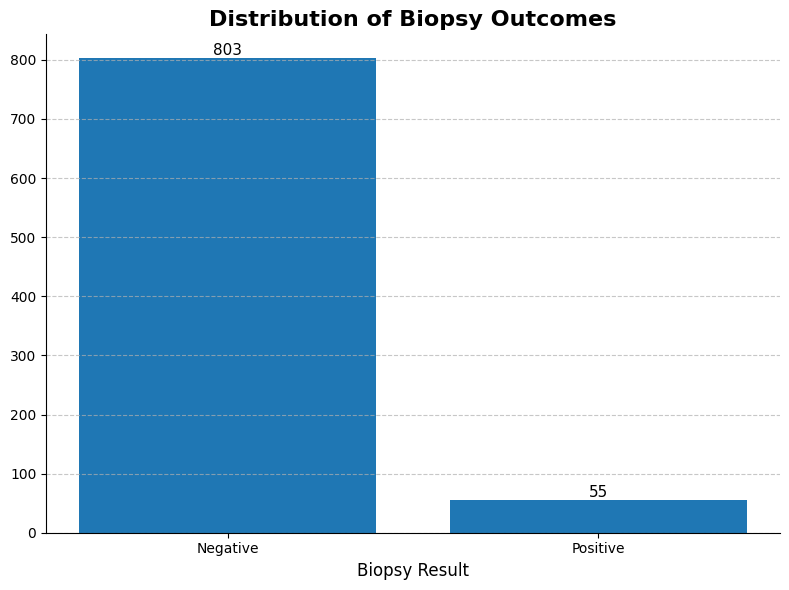

In [ ]:
def plot_biopsy_distribution(y, filename='biopsy_class_distribution.png'):
    plt.figure(figsize=(8, 6))

    # Get unique classes and their counts from the target variable 'y'
    classes, counts = np.unique(y, return_counts=True)
    # Create a bar plot using the classes and their counts
    bars = plt.bar(classes, counts)


    plt.title("Distribution of Biopsy Outcomes", fontsize=16, fontweight='bold')
    plt.xlabel("Biopsy Result", fontsize=12)

    if set(classes) == {0, 1}:
        plt.xticks(classes, ["Negative", "Positive"])

    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                 f'{int(height)}',
                 ha='center', va='bottom', fontsize=11)

    # Hide the top and right spines of the plot for a cleaner look
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

plot_biopsy_distribution(y)

The distribution of the target variable (Biopsy) highlights a significant class imbalance, with 803 negative cases and only 55 positive cases. This imbalance suggests that the dataset is dominated by non-cancer instances, which could lead to biased model predictions if not properly addressed.

### 1.1.2 Lifestyle Variables Distribution

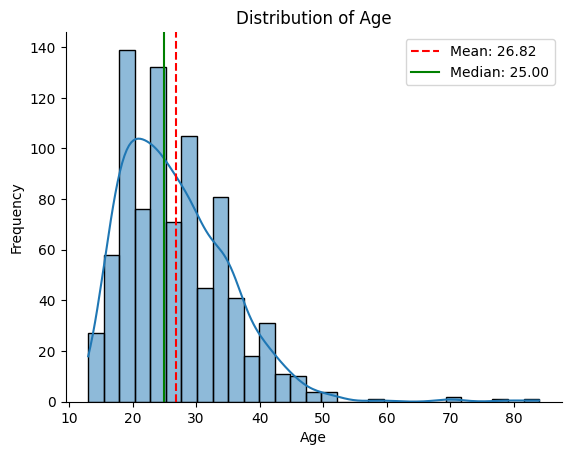

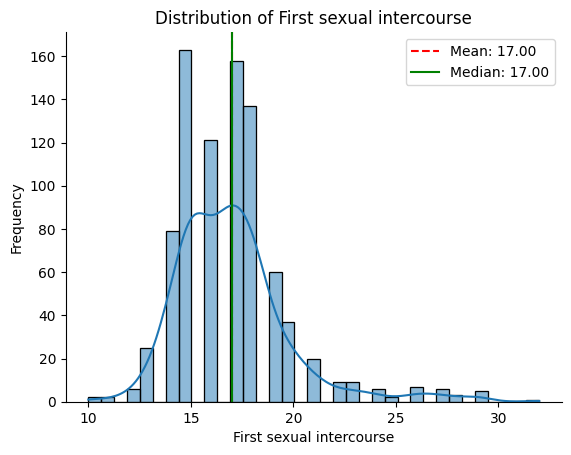

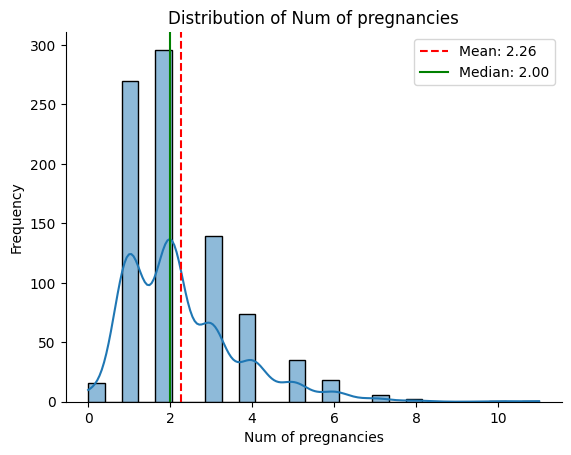

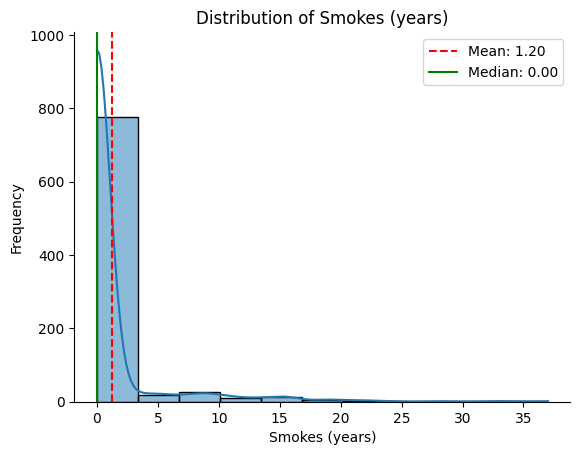

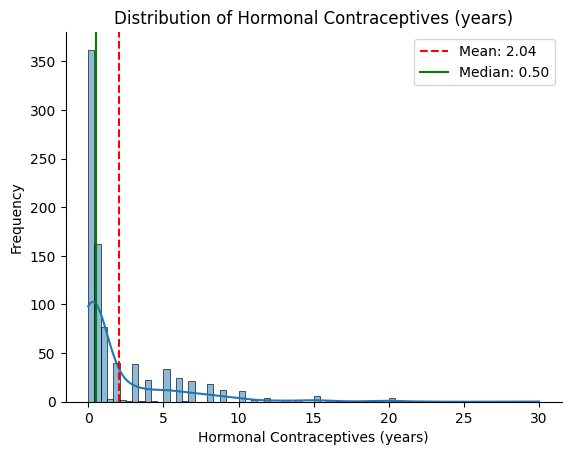

In [ ]:
def plot_lifestyle_distribution(data_df, col):
    plt.figure()
    sns.histplot(data=data_df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Calculate mean and median
    mean_val = data_df[col].mean()
    median_val = data_df[col].median()

    # Add vertical lines for mean and median
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')
    plt.legend()
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.savefig(f'distribution_of_{col.lower().replace(" ", "_")}.png')
    plt.show()

lifestyle_variables = ['Age', 'First sexual intercourse',
                       'Num of pregnancies', 'Smokes (years)', 'Hormonal Contraceptives (years)']

# Loop through the lifestyle variables and call the function for each
for col in lifestyle_variables:
    plot_lifestyle_distribution(X, col)

The lifestyle visualizations reveal that most of these risk factors, such as 'First sexual intercourse', 'Num of pregnancies', 'Smokes (years)', and 'Hormonal Contraceptives (years)', exhibit right-skewed distributions. This indicates that a larger portion of the population in the dataset tends to have lower values for these variables. 'Age' shows a more balanced distribution but still leans towards younger individuals. The mean and median lines on each plot help in understanding the central tendency and the skewness of each variable's distribution.

### 1.1.3 Correlation Matrix
The correlation heatmap primarily focuses on variables that show a positive relationship with the biopsy outcome. Strong positive correlations are observed among screening and clinical variables, indicating their close association with confirmed cervical cancer cases. In contrast, demographic and lifestyle factors exhibit weaker correlations.
These findings help identify the most relevant features for prediction and inform feature selection for the machine learning models.

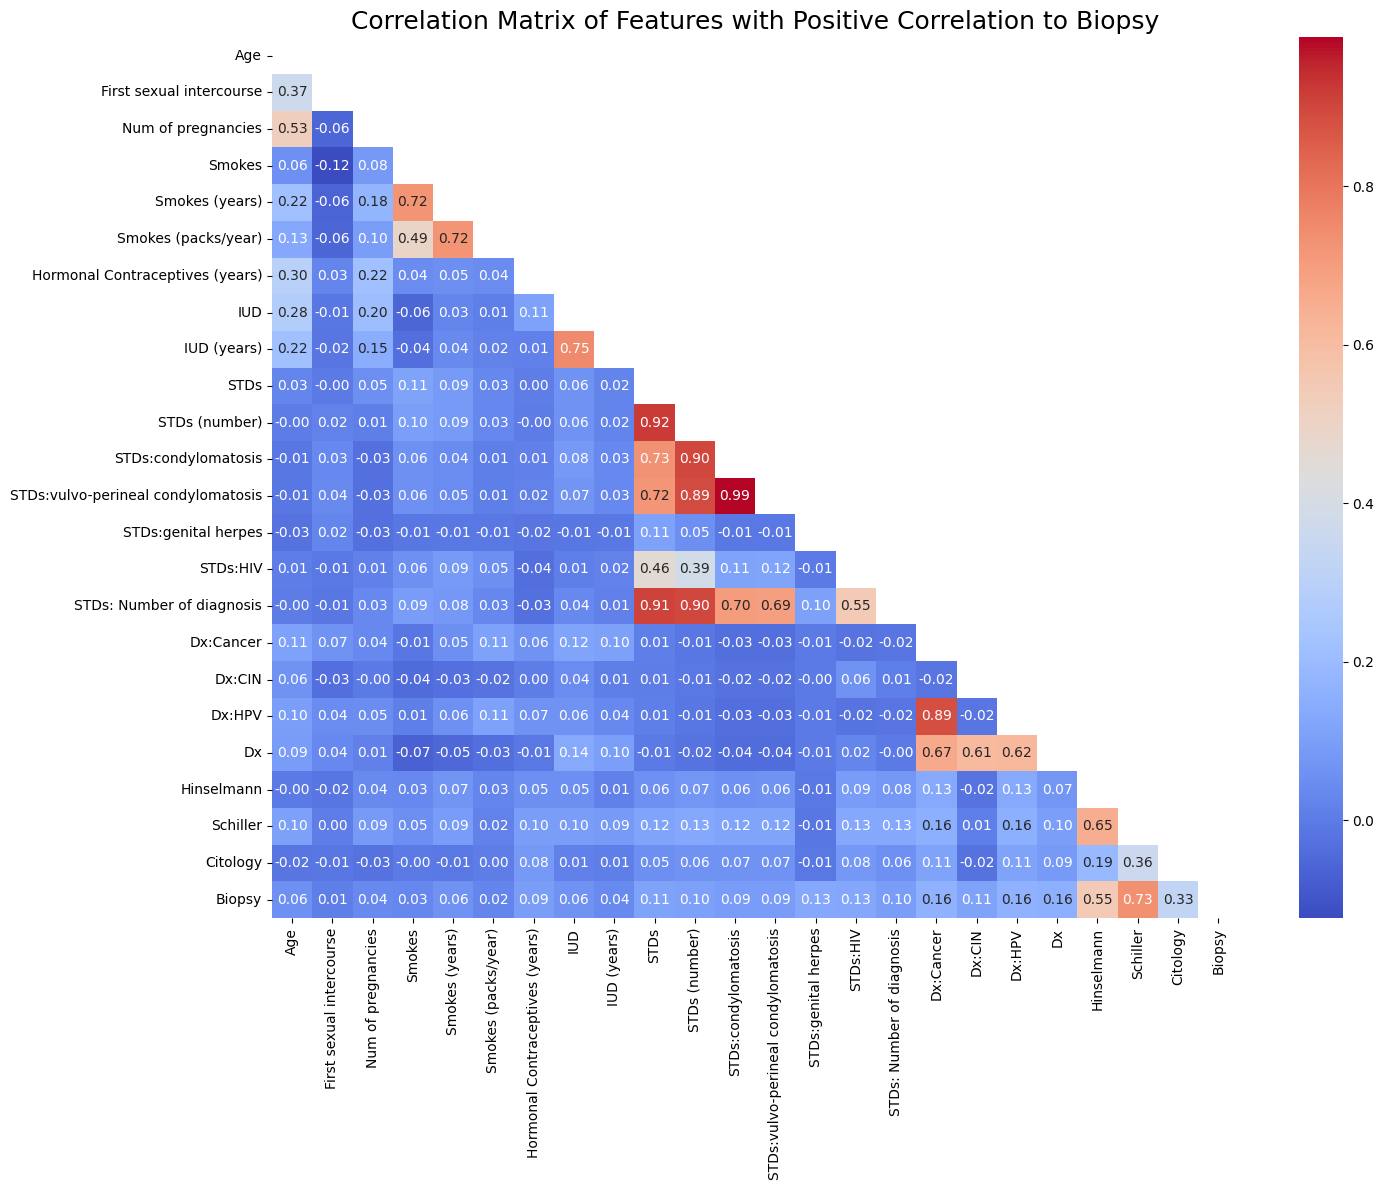

In [ ]:
def plot_positive_correlation_matrix(data, filename='positive_correlation_matrix.png'):
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Ensure 'Biopsy' is included
    if 'Biopsy' not in positive_corr_features:
        positive_corr_features.append('Biopsy')

    filtered_data = data[positive_corr_features]
    corr_matrix = filtered_data.corr()

    # Mask upper triangle to remove repetition
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    plt.figure(figsize=(15, 12))
    sns.heatmap(
        corr_matrix,
        mask=mask,
        annot=True,
        cmap='coolwarm',
        fmt=".2f"
    )

    plt.title('Correlation Matrix of Features with Positive Correlation to Biopsy', fontsize=18)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

plot_positive_correlation_matrix(data)

## **1.2 Train/Test Split**

The dataset was split into training (80%) and testing (20%) sets to evaluate model performance on unseen data. Stratified sampling was used to maintain the class distribution of the target variable (Biopsy), and a fixed random state ensured reproducibility.
Feature scaling was applied using StandardScaler, fitted on the training data and applied to the test data to prevent data leakage.

In [ ]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=50
)

# StandardScaler:
# Standardizes features by removing the mean and scaling to unit variance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Print the shapes of the resulting datasets to verify the split
print(X_test.shape)
print(y_test.shape)
print(X_train.shape)
print(y_train.size)


(172, 20)
(172,)
(686, 20)
686


In [ ]:
# Calculate scale_pos_weight for XGBoost
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight_value = neg_count / pos_count
print(f"Scale Positive Weight: {scale_pos_weight_value:.2f}")

Scale Positive Weight: 14.59


## **1.3 LOGISTIC REGRESSION**
Logistic Regression was used as a baseline model for predicting biopsy outcomes. It is suitable for binary classification and provides good interpretability of feature effects.
The model was trained on scaled data and evaluated using accuracy, precision, recall, and F1-score, with emphasis on recall for detecting positive cases.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score


log_model = LogisticRegression(
    max_iter=1000, random_state=50, class_weight='balanced'
    )

# Train the logistic regression model on the scaled training data
log_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_log = log_model.predict(X_test_scaled)

# Get probabilities for the positive class for ROC-AUC calculation
y_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression (Standard)")
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))

Logistic Regression (Standard)
              precision    recall  f1-score   support

         0.0       0.94      0.83      0.88       161
         1.0       0.07      0.18      0.10        11

    accuracy                           0.79       172
   macro avg       0.50      0.51      0.49       172
weighted avg       0.88      0.79      0.83       172

ROC-AUC: 0.4802371541501976


Random Oversampling was applied to the logistic model to address class imbalance by increasing minority class samples.



In [ ]:
import imblearn
from imblearn.over_sampling import RandomOverSampler
oversample = RandomOverSampler(sampling_strategy='minority', random_state=50)
X_over, y_over = oversample.fit_resample(X_train_scaled, y_train)

In [ ]:
# Create a new Logistic Regression model and train it on the oversampled data.
log_oversampled = LogisticRegression(max_iter=1000, random_state=50, class_weight='balanced')
log_oversampled.fit(X_over, y_over)

y_pred_log_over = log_oversampled.predict(X_test_scaled)
y_proba_log_over = log_oversampled.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression with oversampling")
print(classification_report(y_test,y_pred_log_over))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log_over))

Logistic Regression with oversampling
              precision    recall  f1-score   support

         0.0       0.94      0.84      0.89       161
         1.0       0.07      0.18      0.10        11

    accuracy                           0.80       172
   macro avg       0.50      0.51      0.49       172
weighted avg       0.88      0.80      0.84       172

ROC-AUC: 0.46160361377752684


## **1.4 XGBoost Model**
XGBoost was used as an advanced ensemble model based on gradient boosting, capable of capturing complex relationships in the data. It includes regularisation to reduce overfitting and performs well on structured datasets.
Hyperparameter tuning was applied to optimise performance, and the model was evaluated using accuracy, precision, recall, and F1-score, with emphasis on detecting positive cases.

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV


# Initialize the XGBoost classifier with a random state for reproducibility.
xgb_model = XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    learning_rate=None,
    max_depth=None,
    subsample=0.8,
    random_state=50,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight_value
)

# Train the XGBoost model on the scaled training data
xgb_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Get probabilities for the positive class for ROC-AUC calculation
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model
print("XGBoost (Standard)")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

XGBoost (Standard)
              precision    recall  f1-score   support

         0.0       0.94      0.98      0.96       161
         1.0       0.20      0.09      0.12        11

    accuracy                           0.92       172
   macro avg       0.57      0.53      0.54       172
weighted avg       0.89      0.92      0.90       172

ROC-AUC: 0.6778656126482213


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold


# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'scale_pos_weight': [1, scale_pos_weight_value / 2, scale_pos_weight_value] # Include scale_pos_weight in tuning
}

# Initialize an XGBoost classifier with specified parameters.
xgb_tuned_model = XGBClassifier(objective='binary:logistic', random_state=50, eval_metric='logloss')

# Define StratifiedKFold for consistent cross-validation
cv_xgb = StratifiedKFold(n_splits=3, shuffle=True, random_state=50)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_tuned_model,
    param_grid=param_grid,
    scoring='f1',
    cv=cv_xgb,
    verbose=1,
    n_jobs=-1
)

# Fit the GridSearchCV to the oversampled training data (X_over, y_over).
grid_search.fit(X_over, y_over)

# Get the best estimator
best_xgb_model = grid_search.best_estimator_

print("Best hyperparameters found:", grid_search.best_params_)

# Make predictions on the scaled test data using the best model
y_pred_xgb_over = best_xgb_model.predict(X_test_scaled)

# Get probabilities for the positive class for ROC-AUC calculation
y_proba_xgb_over = best_xgb_model.predict_proba(X_test_scaled)[:, 1]

Fitting 3 folds for each of 729 candidates, totalling 2187 fits
Best hyperparameters found: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100, 'scale_pos_weight': 1, 'subsample': 0.8}


Threshold Tuning for Recall and F1 Score

In this section, we evaluate how different classification thresholds affect model performance, specifically focusing on recall and F1 score.

In [ ]:
# Evaluate the model with 0.05 threshold
print("\nXGBoost evalution with oversamplong and 0.05 threshold:")
y_pred_with_0_05_threshold = (y_proba_xgb_over >= 0.05).astype(int)
print(classification_report(y_test, y_pred_with_0_05_threshold))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb_over))



XGBoost evalution with oversamplong and 0.05 threshold:
              precision    recall  f1-score   support

         0.0       0.97      0.79      0.87       161
         1.0       0.17      0.64      0.27        11

    accuracy                           0.78       172
   macro avg       0.57      0.71      0.57       172
weighted avg       0.92      0.78      0.83       172

ROC-AUC: 0.7213438735177866


# **1.5 RANDOM FOREST**
Random Forest was used as an ensemble model that combines multiple decision trees to improve accuracy and reduce overfitting. It can capture non-linear relationships and provides feature importance insights.
The model was evaluated using accuracy, precision, recall, and F1-score, with emphasis on detecting positive cases.

In [ ]:
# Define the Random Forest classifier model with a fixed random state for reproducibility.
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=50
)

# Fit the model to the scaled training data.
rf.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data.
y_predrf = rf.predict(X_test_scaled)

# Predict probabilities for the positive class (class 1) on the scaled test data.
y_proba_rf = rf.predict_proba(X_test_scaled)[:,1]

# Evaluate the model's performance without oversampling.
print("Random Forest (standard, no oversampling)")
print(classification_report(y_test, y_predrf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

Random Forest (standard, no oversampling)
              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97       161
         1.0       0.00      0.00      0.00        11

    accuracy                           0.94       172
   macro avg       0.47      0.50      0.48       172
weighted avg       0.88      0.94      0.91       172

ROC-AUC: 0.6453980801806889


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.model_selection import StratifiedKFold
# Define the parameter grid for GridSearchCV for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced'] # Keep balanced class weight
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=50)

# Initialize a Random Forest classifier
rf_tuned_model = RandomForestClassifier(random_state=50)

# Set up GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=rf_tuned_model,
    param_grid=param_grid_rf,
    scoring='recall', # Optimize for recall
    cv=cv,
    verbose=1,
    n_jobs=-1
)

# Fit the GridSearchCV to the oversampled training data
grid_search_rf.fit(X_over, y_over)

# Get the best estimator
best_rf_model = grid_search_rf.best_estimator_

print("Best hyperparameters found for Random Forest:", grid_search_rf.best_params_)

# Make predictions on the scaled test data using the best model
y_pred_rf_over = best_rf_model.predict(X_test_scaled)

# Get probabilities for the positive class for ROC-AUC calculation
y_proba_rf_over = best_rf_model.predict_proba(X_test_scaled)[:, 1]

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best hyperparameters found for Random Forest: {'class_weight': 'balanced', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
from sklearn.metrics import recall_score, f1_score

thresholds = np.linspace(0, 1, 100)

recalls = []
f1s = []

for t in thresholds:
    y_pred = (y_proba_rf_over > t).astype(int)

    recalls.append(recall_score(y_test, y_pred))
    f1s.append(f1_score(y_test, y_pred))

# Best thresholds
best_t_recall = thresholds[np.argmax(recalls)]
best_t_f1 = thresholds[np.argmax(f1s)]

print("\nComparison:")
print(f"Recall-optimal threshold: {best_t_recall:.3f}")
print(f"F1-optimal threshold: {best_t_f1:.3f}")


Comparison:
Recall-optimal threshold: 0.000
F1-optimal threshold: 0.475


In [ ]:

# Evaluate the model's performance.
print("Random Forest with oversampling and 0.05 threshold")
y_pred_with_threshold = (y_proba_rf_over >= 0.05).astype(int)
print(classification_report(y_test, y_pred_with_threshold))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf_over))

Random Forest with oversampling and 0.05 threshold
              precision    recall  f1-score   support

         0.0       0.97      0.42      0.59       161
         1.0       0.09      0.82      0.16        11

    accuracy                           0.45       172
   macro avg       0.53      0.62      0.37       172
weighted avg       0.91      0.45      0.56       172

ROC-AUC: 0.6614906832298137


# **ROC Curve Comparison**

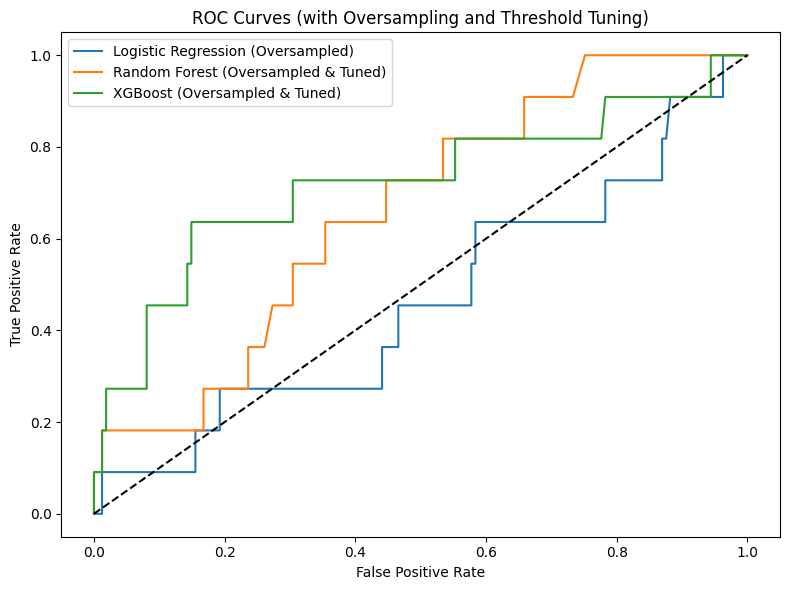

In [ ]:
from sklearn.metrics import roc_curve

def plot_roc_curves_comparison(models_to_plot, y_true, X_data_common, filename='roc_curve_with_oversampling_tuned.png'):
    plt.figure(figsize=(8, 6))

    for model, name in models_to_plot:
        probs = model.predict_proba(X_data_common)[:,1]
        fpr, tpr, _ = roc_curve(y_true, probs)
        plt.plot(fpr, tpr, label=name)

    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves (with Oversampling and Threshold Tuning)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

# Prepare the data for the function call
models_info = [
    (log_oversampled, "Logistic Regression (Oversampled)"),
    (best_rf_model, "Random Forest (Oversampled & Tuned)"),
    (best_xgb_model, "XGBoost (Oversampled & Tuned)")
]

plot_roc_curves_comparison(models_info, y_test, X_test_scaled)

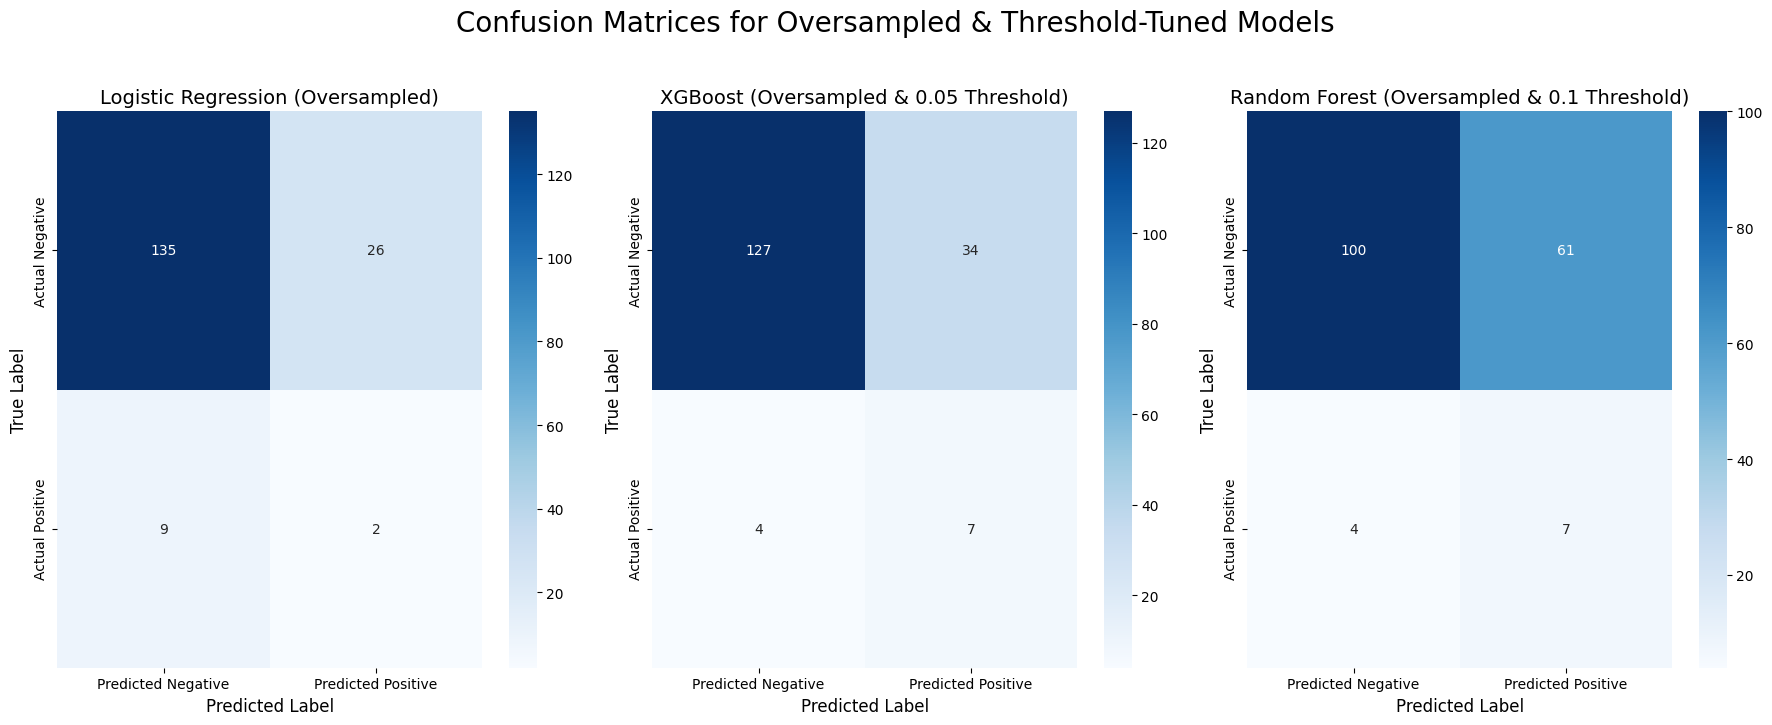

In [ ]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrices(model_eval_info, y_true, filename='confusion_matrices_oversampled_tuned.png'):
    fig, axes = plt.subplots(1, len(model_eval_info), figsize=(6 * len(model_eval_info), 7)) # Adjusted figsize dynamically
    axes = axes.flatten()

    fig.suptitle('Confusion Matrices for Oversampled & Threshold-Tuned Models', fontsize=20, y=1.03)

    for i, model_info in enumerate(model_eval_info):
        ax = axes[i]
        y_pred = (model_info["y_proba"] >= model_info["threshold"]).astype(int)
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Predicted Negative', 'Predicted Positive'],
                    yticklabels=['Actual Negative', 'Actual Positive'])
        ax.set_title(f'{model_info["name"]}', fontsize=14)
        ax.set_xlabel('Predicted Label', fontsize=12)
        ax.set_ylabel('True Label', fontsize=12)

    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    plt.show()

# Define the models and their respective probability predictions and optimal thresholds
model_eval_info = [
    {
        "name": "Logistic Regression (Oversampled)",
        "y_proba": y_proba_log_over,
        "threshold": 0.5
    },
    {
        "name": "XGBoost (Oversampled & 0.05 Threshold)",
        "y_proba": y_proba_xgb_over,
        "threshold": 0.05
    },
    {
        "name": "Random Forest (Oversampled & 0.1 Threshold)",
        "y_proba": y_proba_rf_over,
        "threshold": 0.1
    }
]

# Call the function to plot the confusion matrices
plot_confusion_matrices(model_eval_info, y_test)

# **GBD PREVALANCE AND INCIDENCE OF CERVICAL CANCER IN WEST AFRICAN COUNTRIES**
This section explores the Global Burden of Disease (GBD) datasets for cervical cancer incidence and prevalence across West African countries.
Two datasets were used:
1.   Incidence dataset: which represents the average rate of new cervical cancer cases per year in West Africa.


2.   Prevalence dataset : which represents the average number of existing cases in the population over time.



In [ ]:
df_incidence = 'https://raw.githubusercontent.com/opeoluwa22/Lifestyle-Based-Cervical-Cancer-Risk-Prediction-/refs/heads/main/data/IHME-GBD_2023_DATA-a243a57e.csv'
incidence = pd.read_csv(df_incidence)
df_prevalence = 'https://raw.githubusercontent.com/opeoluwa22/Lifestyle-Based-Cervical-Cancer-Risk-Prediction-/refs/heads/main/data/IHME-GBD_2023_DATA-ee7a3b09.csv'
prevalence = pd.read_csv(df_prevalence)

In [ ]:
incidence = incidence[['measure_name','location_name','age_name','year','val', 'upper', 'lower']]
incidence.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1368 entries, 0 to 1367
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   measure_name   1368 non-null   object 
 1   location_name  1368 non-null   object 
 2   age_name       1368 non-null   object 
 3   year           1368 non-null   int64  
 4   val            1368 non-null   float64
 5   upper          1368 non-null   float64
 6   lower          1368 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 74.9+ KB


In [ ]:
prevalence = prevalence[['measure_name','location_name','age_name','year','val', 'upper', 'lower']]
prevalence.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1425 entries, 0 to 1424
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   measure_name   1425 non-null   object 
 1   location_name  1425 non-null   object 
 2   age_name       1425 non-null   object 
 3   year           1425 non-null   int64  
 4   val            1425 non-null   float64
 5   upper          1425 non-null   float64
 6   lower          1425 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 78.1+ KB


This enables analysis of:

*  Disease burden trends across West African countries
*   Differences between new infections and overall burden
*   Temporal changes in cervical cancer impact


## **EXPLORATORY DATA ANALYSIS**

In [ ]:
age_midpoints = {
        '15-49 years': 32.0,
        '50-69 years': 59.5,
        '70+ years': 75.0
    }

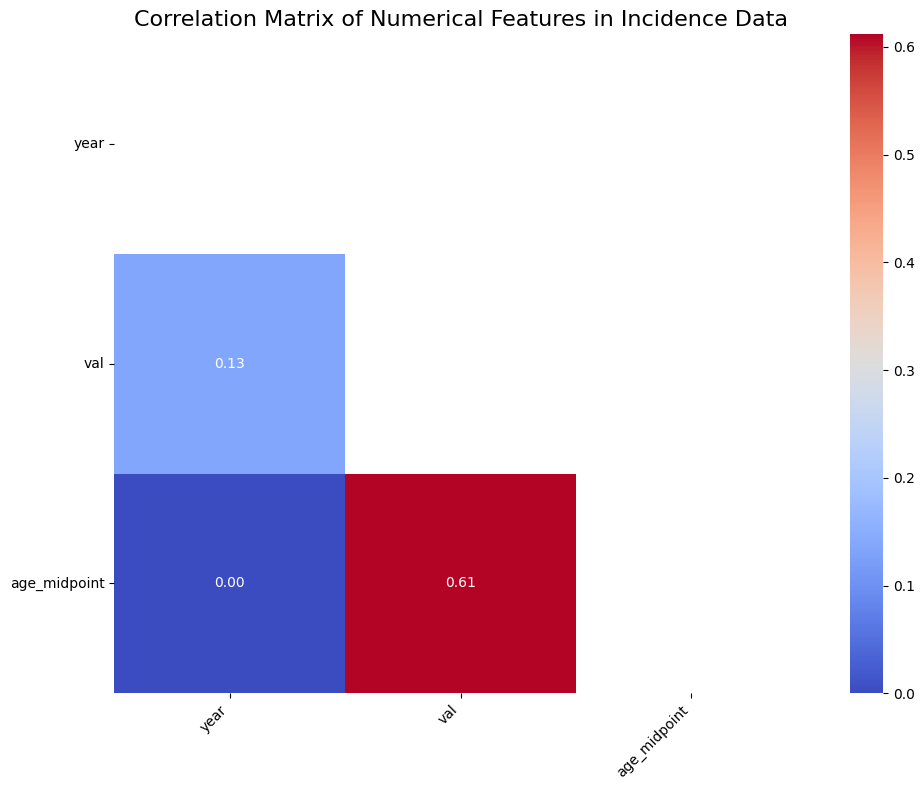

In [ ]:
def plot_incidence_correlation_matrix(incidence_df, filename='incidence_correlation_heatmap.png'):
    # Map age_name to numerical midpoints for correlation analysis

    incidence_df['age_midpoint'] = incidence_df['age_name'].map(age_midpoints)

    numerical_incidence_data = incidence_df[['year', 'val', 'age_midpoint']]
    correlation_matrix_incidence = numerical_incidence_data.corr()

    # Mask upper triangle
    mask = np.triu(np.ones_like(correlation_matrix_incidence, dtype=bool))

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix_incidence,
                mask=mask,
                annot=True,
                cmap='coolwarm',
                fmt=".2f")

    plt.title('Correlation Matrix of Numerical Features in Incidence Data', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

plot_incidence_correlation_matrix(incidence)

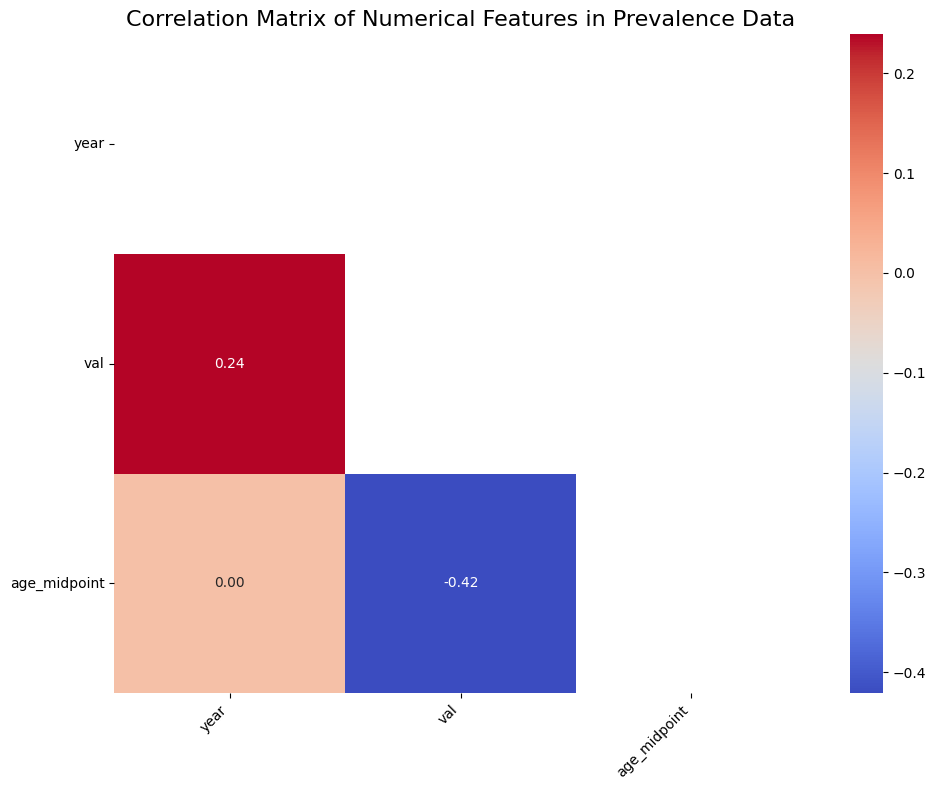

In [ ]:
def plot_prevalence_correlation_matrix(prevalence_df, filename='prevalence_correlation_heatmap.png'):
    # Map age_name to numerical midpoints for correlation analysis

    prevalence_df['age_midpoint'] = prevalence_df['age_name'].map(age_midpoints)

    numerical_prevalence_data = prevalence_df[['year', 'val', 'age_midpoint']]
    correlation_matrix_prevalence = numerical_prevalence_data.corr()

    # Mask upper triangle
    mask = np.triu(np.ones_like(correlation_matrix_prevalence, dtype=bool))

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix_prevalence,
                mask=mask,
                annot=True,
                cmap='coolwarm',
                fmt=".2f")

    plt.title('Correlation Matrix of Numerical Features in Prevalence Data', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

plot_prevalence_correlation_matrix(prevalence)

### **Regional Trend (Average Across West Africa)**

To understand the overall burden of cervical cancer in West Africa, the incidence and prevalence values were aggregated across all selected countries and averaged by year. This provides a regional-level trend rather than country-specific variation. The results show how cervical cancer burden changes over time across the region. By comparing these two trends, we can observe whether the disease burden is increasing due to higher new case detection, or sustained due to long-term survival and accumulation of cases.

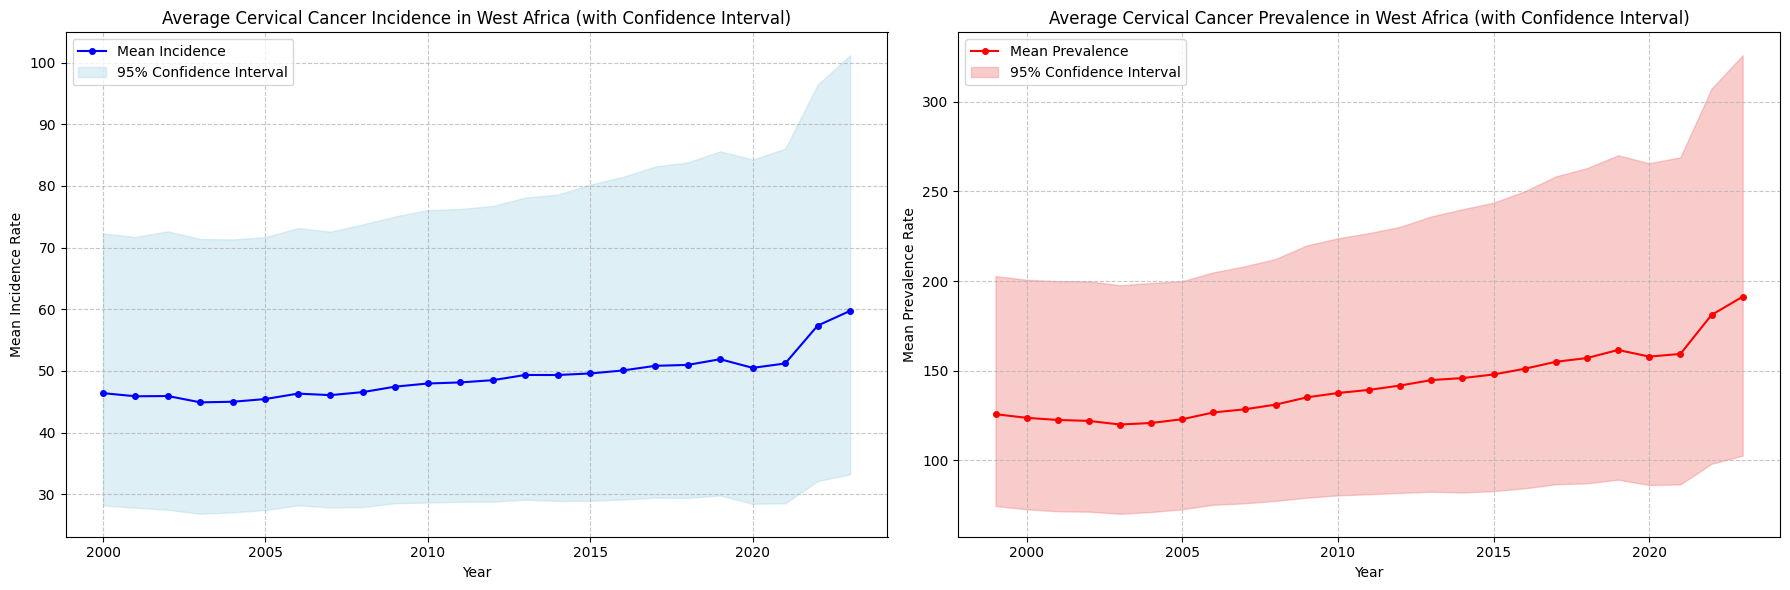

In [ ]:
def plot_regional_trends(incidence_df, prevalence_df):
    regional_incidence_trend = (
        incidence_df.groupby("year")[["val", "upper", "lower"]]
        .mean()
        .reset_index()
    )

    regional_prevalence_trend = (
        prevalence_df.groupby("year")[["val", "upper", "lower"]]
        .mean()
        .reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Plot for Incidence
    axes[0].plot(regional_incidence_trend["year"], regional_incidence_trend["val"],
                 label="Mean Incidence", color='blue', marker='o', markersize=4)
    axes[0].fill_between(regional_incidence_trend["year"], regional_incidence_trend["lower"],
                         regional_incidence_trend["upper"], color='lightblue', alpha=0.4,
                         label="95% Confidence Interval")
    axes[0].set_title("Average Cervical Cancer Incidence in West Africa (with Confidence Interval)")
    axes[0].set_xlabel("Year")
    axes[0].set_ylabel("Mean Incidence Rate")
    axes[0].grid(True, linestyle='--', alpha=0.7)
    axes[0].legend()

    # Plot for Prevalence
    axes[1].plot(regional_prevalence_trend["year"], regional_prevalence_trend["val"],
                 label="Mean Prevalence", color='red', marker='o', markersize=4)
    axes[1].fill_between(regional_prevalence_trend["year"], regional_prevalence_trend["lower"],
                         regional_prevalence_trend["upper"], color='lightcoral', alpha=0.4,
                         label="95% Confidence Interval")
    axes[1].set_title("Average Cervical Cancer Prevalence in West Africa (with Confidence Interval)")
    axes[1].set_xlabel("Year")
    axes[1].set_ylabel("Mean Prevalence Rate")
    axes[1].grid(True, linestyle='--', alpha=0.7)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('regional_incidence_prevalence_trends.png')
    plt.show()

plot_regional_trends(incidence, prevalence)

### **Cervical Cancer Prevalence and Incidence Comparison**
This analysis compares cervical cancer incidence and prevalence among women aged 15–49 years across West African countries using the most recent available GBD data.
The focus on the 15–49 age group is important because it represents the primary reproductive and high-risk population, where early detection and prevention strategies are most impactful.


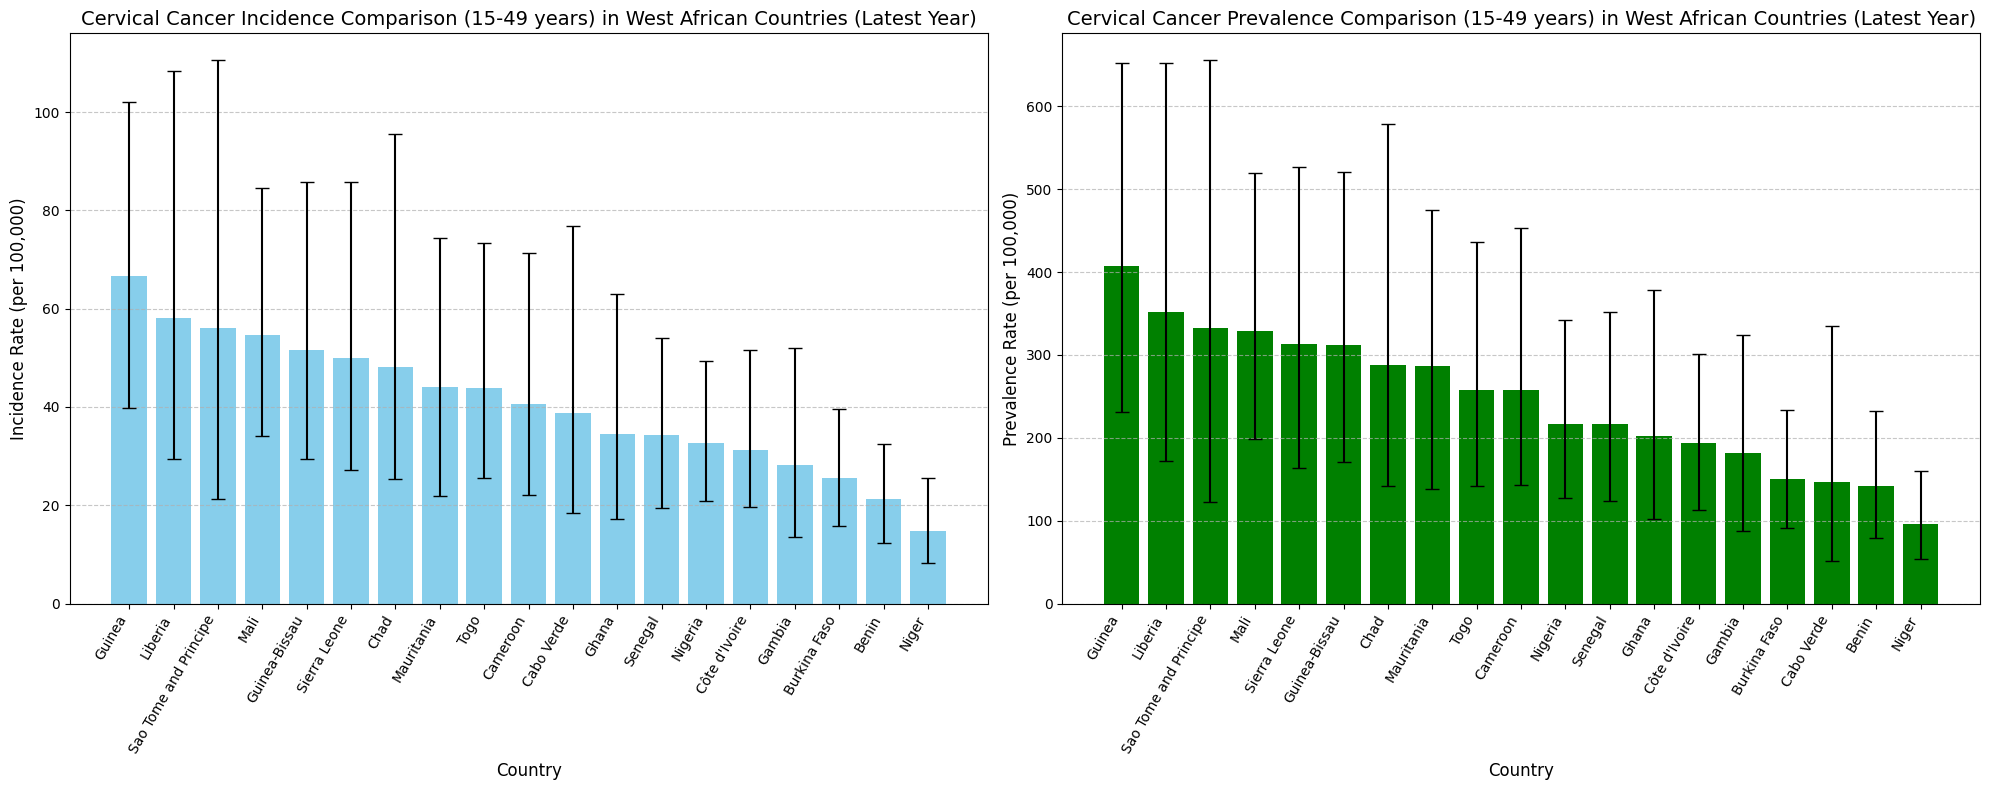

In [ ]:
def plot_country_comparison_incidence_prevalence(incidence_df, prevalence_df, filename='country_comparison_incidence_prevalence.png'):
    latest_year = incidence_df["year"].max()

    # --- Incidence Data Processing ---
    latest_incidence = incidence_df[
        (incidence_df["year"] == latest_year) &
        (incidence_df["age_name"] == "15-49 years")
    ]
    latest_incidence_sorted = latest_incidence.sort_values("val", ascending=False)

    incidence_lower_errors = latest_incidence_sorted["val"] - latest_incidence_sorted["lower"]
    incidence_upper_errors = latest_incidence_sorted["upper"] - latest_incidence_sorted["val"]

    # --- Prevalence Data Processing ---
    latest_prevalence = prevalence_df[
        (prevalence_df["year"] == latest_year) &
        (prevalence_df["age_name"] == "15-49 years")
    ]
    latest_prevalence_sorted = latest_prevalence.sort_values("val", ascending=False)

    prevalence_lower_errors = latest_prevalence_sorted["val"] - latest_prevalence_sorted["lower"]
    prevalence_upper_errors = latest_prevalence_sorted["upper"] - latest_prevalence_sorted["val"]

    # --- Plotting ---
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Plot for Incidence
    axes[0].bar(
        x=latest_incidence_sorted["location_name"],
        height=latest_incidence_sorted["val"],
        yerr=[incidence_lower_errors, incidence_upper_errors],
        capsize=5,
        color='skyblue'
    )
    axes[0].set_xticks(range(len(latest_incidence_sorted["location_name"])))
    axes[0].set_xticklabels(latest_incidence_sorted["location_name"], rotation=60, ha='right')
    axes[0].set_title(
        "Cervical Cancer Incidence Comparison (15-49 years) in West African Countries (Latest Year)",
                      fontsize=14
        )
    axes[0].set_xlabel("Country", fontsize=12)
    axes[0].set_ylabel("Incidence Rate (per 100,000)", fontsize=12)
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)

    # Plot for Prevalence
    axes[1].bar(
        x=latest_prevalence_sorted["location_name"],
        height=latest_prevalence_sorted["val"],
        yerr=[prevalence_lower_errors, prevalence_upper_errors],
        capsize=5,
        color='green'
    )
    axes[1].set_xticks(range(len(latest_prevalence_sorted["location_name"])))
    axes[1].set_xticklabels(latest_prevalence_sorted["location_name"], rotation=60, ha='right')
    axes[1].set_title(
        "Cervical Cancer Prevalence Comparison (15-49 years) in West African Countries (Latest Year)",
                      fontsize=14
        )
    axes[1].set_xlabel("Country", fontsize=12)
    axes[1].set_ylabel("Prevalence Rate (per 100,000)", fontsize=12)
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

plot_country_comparison_incidence_prevalence(incidence, prevalence)

###**Average Cervical Cancer Prevalence and Incidence by Age Group**

This analysis examines the average cervical cancer incidence and prevalence across different age groups using the most recent GBD data. The results are aggregated to show how disease burden varies with age.

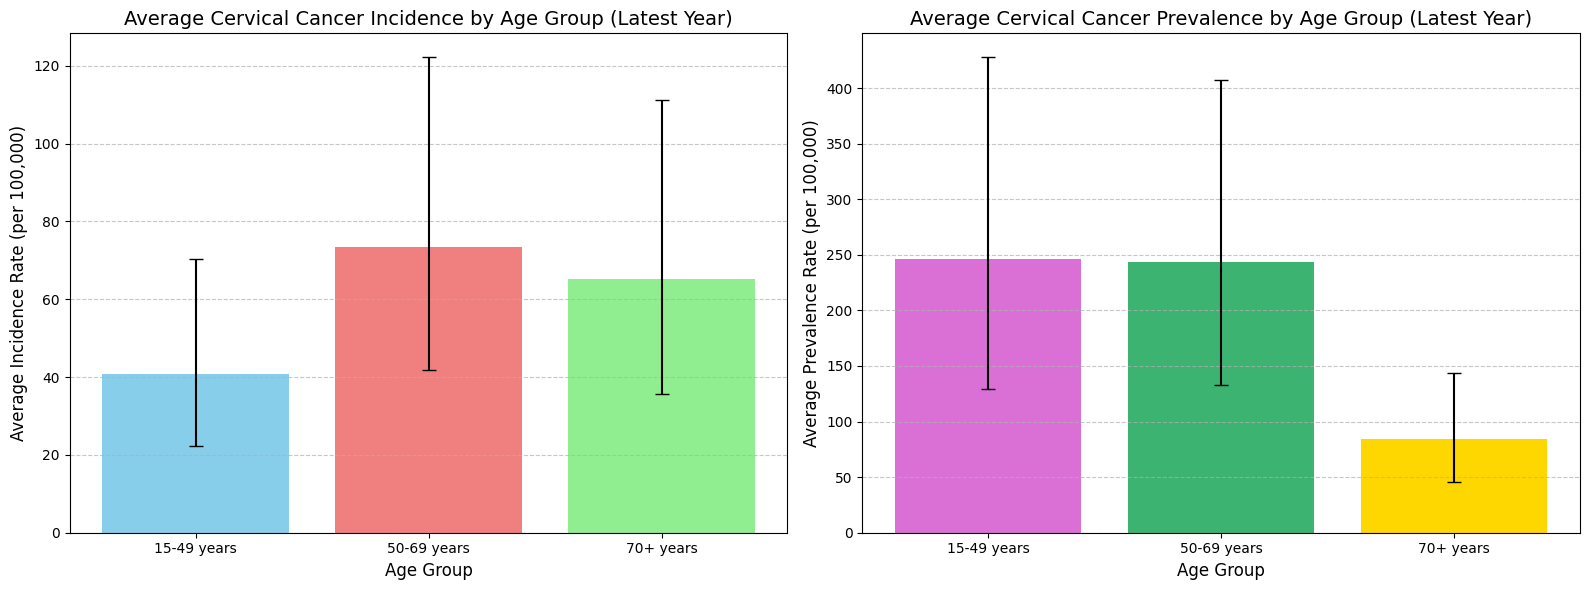

In [ ]:
def plot_age_group_comparison(incidence_df, prevalence_df, filename='age_group_incidence_prevalence.png'):
    latest_year = incidence_df["year"].max()

    # Incidence Data Processing
    latest_incidence_age = incidence_df[incidence_df["year"] == latest_year]
    incidence_age_group_data = (
        latest_incidence_age.groupby("age_name")[["val", "upper", "lower"]]
        .mean()
        .reset_index()
    )

    # Prevalence Data Processing
    latest_prevalence_age = prevalence_df[prevalence_df["year"] == latest_year]
    prevalence_age_group_data = (
        latest_prevalence_age.groupby("age_name")[["val", "upper", "lower"]]
        .mean()
        .reset_index()
    )

    # Define a specific order for age groups
    age_order = ["15-49 years", "50-69 years", "70+ years"]

    incidence_age_group_data["age_name"] = pd.Categorical(
        incidence_age_group_data["age_name"],
        categories=age_order,
        ordered=True,
    )
    incidence_age_group_data = incidence_age_group_data.sort_values(
        "age_name"
    )

    prevalence_age_group_data["age_name"] = pd.Categorical(
        prevalence_age_group_data["age_name"],
        categories=age_order,
        ordered=True,
    )
    prevalence_age_group_data = prevalence_age_group_data.sort_values(
        "age_name"
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # Create a figure with 2 subplots

    # Plot for Incidence by Age Group
    incidence_lower_errors = (
        incidence_age_group_data["val"] - incidence_age_group_data["lower"]
    )
    incidence_upper_errors = (
        incidence_age_group_data["upper"] - incidence_age_group_data["val"]
    )

    axes[0].bar(
        x=incidence_age_group_data["age_name"],
        height=incidence_age_group_data["val"],
        yerr=[incidence_lower_errors, incidence_upper_errors],
        capsize=5,
        color=['skyblue', 'lightcoral', 'lightgreen'],
    )
    axes[0].set_title(
        "Average Cervical Cancer Incidence by Age Group (Latest Year)",
        fontsize=14,
    )
    axes[0].set_xlabel("Age Group", fontsize=12)
    axes[0].set_ylabel("Average Incidence Rate (per 100,000)", fontsize=12)
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)

    # Plot for Prevalence by Age Group
    prevalence_lower_errors = (
        prevalence_age_group_data["val"] - prevalence_age_group_data["lower"]
    )
    prevalence_upper_errors = (
        prevalence_age_group_data["upper"] - prevalence_age_group_data["val"]
    )

    axes[1].bar(
        x=prevalence_age_group_data["age_name"],
        height=prevalence_age_group_data["val"],
        yerr=[prevalence_lower_errors, prevalence_upper_errors],
        capsize=5,
        color=['orchid', 'mediumseagreen', 'gold'],  # Different colors for prevalence
    )
    axes[1].set_title(
        "Average Cervical Cancer Prevalence by Age Group (Latest Year)",
        fontsize=14,
    )
    axes[1].set_xlabel("Age Group", fontsize=12)
    axes[1].set_ylabel("Average Prevalence Rate (per 100,000)", fontsize=12)
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

plot_age_group_comparison(incidence, prevalence)